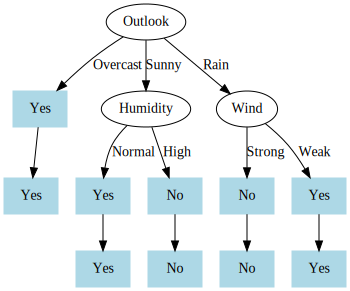

In [ ]:
import csv
import math
from collections import Counter
from graphviz import Digraph

# Load CSV into a list of rows
def load_csv(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        data = list(reader)
    header = data[0]
    rows = data[1:]
    return header, rows

# Calculate entropy
def entropy(data):
    labels = [row[-1] for row in data]
    total = len(labels)
    label_counts = Counter(labels)
    return -sum((count/total) * math.log2(count/total) for count in label_counts.values())

# Split dataset based on a feature value
def split_data(data, index, value):
    return [row for row in data if row[index] == value]

# Compute information gain
def info_gain(data, index):
    base_entropy = entropy(data)
    values = set(row[index] for row in data)
    subset_entropy = 0
    for value in values:
        subset = split_data(data, index, value)
        subset_entropy += (len(subset)/len(data)) * entropy(subset)
    return base_entropy - subset_entropy

# ID3 Algorithm
def id3(data, features):
    labels = [row[-1] for row in data]
    if labels.count(labels[0]) == len(labels):
        return labels[0]
    if not features:
        return Counter(labels).most_common(1)[0][0]

    gains = [info_gain(data, i) for i in range(len(features))]
    best_index = gains.index(max(gains))
    best_feature = features[best_index]

    tree = {best_feature: {}}
    feature_values = set(row[best_index] for row in data)

    for value in feature_values:
        subset = split_data(data, best_index, value)
        new_features = features[:best_index] + features[best_index+1:]
        reduced_data = [row[:best_index] + row[best_index+1:] for row in subset]
        subtree = id3(reduced_data, new_features)
        tree[best_feature][value] = subtree
    return tree

# Graphviz Tree Visualization
from graphviz import Digraph

# Updated draw_tree to use actual root attribute as label
def draw_tree(tree, dot=None, parent=None):
    if dot is None:
        dot = Digraph()

        # Get the root attribute (first key in the dict)
        root_attr = next(iter(tree))
        root_id = str(id(tree))
        dot.node(root_id, root_attr)
        parent = root_id  # Set root_id as parent for children

    if not isinstance(tree, dict):
        node_id = str(id(tree)) + '_leaf'
        dot.node(node_id, tree, shape='box', style='filled', color='lightblue')
        dot.edge(parent, node_id)
        return dot

    for feature, branches in tree.items():
        for val, subtree in branches.items():
            node_id = str(id(subtree))
            if isinstance(subtree, dict):
                # Use the attribute name at this subtree
                label = next(iter(subtree)) if isinstance(subtree, dict) else subtree
                dot.node(node_id, label)
            else:
                dot.node(node_id, subtree, shape='box', style='filled', color='lightblue')

            dot.edge(parent, node_id, label=val)
            draw_tree(subtree, dot, node_id)

    return dot
# Load your dataset
header, rows = load_csv('weather.csv')

# Build the decision tree
tree = id3(rows, header[:-1])

# Visualize the tree
dot = draw_tree(tree)
dot.render('id3_tree', format='png', cleanup=True)
dot